In [6]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u

from config.plotting import set_plotting_defaults
from config.units import Gauss

from electron_model_constraints import (propagation_timescale,
                                        synch_cutoff_timescale,
                                        diffusion_timescale)

from src.electron_timescales import electron_inverse_compton_timescale

set_plotting_defaults()

In [7]:
theta = np.linspace(0, 90, 501) * u.deg
bfield = np.logspace(-2, 1, 901) * 1e-6 * Gauss

tb, bt = np.meshgrid(theta, bfield, indexing='xy')
length = np.array([138]) * u.pc  # LHAASO
energy = np.array([100]) * u.TeV

In [8]:
# Get propagation timescale
t_prop = propagation_timescale(distance=length, theta=tb)

# Get synchrotron cutoff timescale
t_cutoff = synch_cutoff_timescale(bfield = bt)

# Get diffusion timescale
t_diff = 2 * diffusion_timescale(distance=length, theta=tb, bfield=bt, energy=energy)

# Get IC timescale
# ToDo: HOW TO CONSTRAIN THE T_IC CORRECTLY???
t_IC = electron_inverse_compton_timescale(energy=energy.to(u.eV))

possible1 = t_cutoff >= t_prop
possible2 = (t_diff >= t_prop) * (t_diff <= t_cutoff)  # diffusion faster than cutoff
possible3 = (t_IC >= t_prop) * (t_IC >= t_diff)

possible_prop = (t_cutoff >= t_prop) * (t_IC >= t_prop)
possible_diff = (t_cutoff >= t_diff) * (t_IC >= t_diff) * (t_diff >= t_prop)

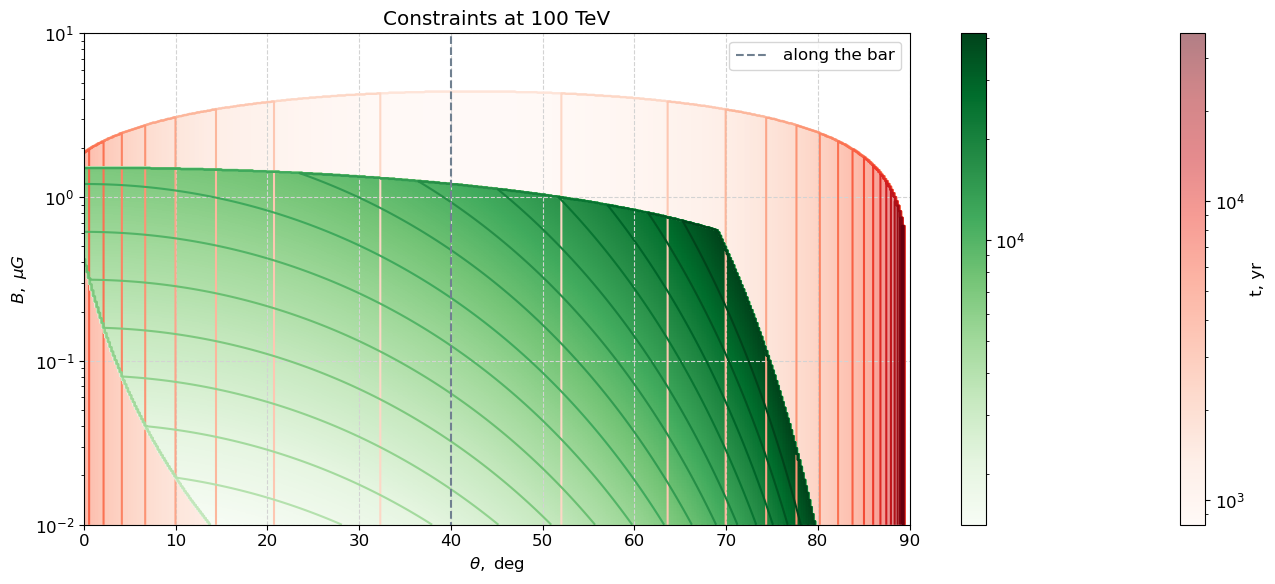

In [9]:
plt.figure(figsize=(14, 6))

plt.title("Constraints at 100 TeV")

X, Y = theta.value, (bfield * 1e6).value
mesh_prop = plt.pcolormesh(X, Y, t_prop.value * possible_prop, cmap='Reds', norm='log', alpha=0.5,)
plt.contour(X, Y, t_prop.value * possible_prop, cmap='Reds', norm='log', alpha=1,
                        levels=np.logspace(2.65, 4.5, 20))

mesh_diff = plt.pcolormesh(X, Y, t_diff.value * possible_diff, cmap='Greens', norm='log', alpha=1)
plt.contour(X, Y, t_diff.value * possible_diff, cmap='Greens', norm='log', alpha=1,
            levels=np.logspace(2.65, 4.5, 20))

plt.vlines([40], 1e-5, 1e5, color='slategray', linestyle='--', label='along the bar')

plt.legend(loc=1)

plt.xlabel(r'$\theta,$ deg')
plt.xlim(0, 90)

plt.yscale('log')
plt.ylabel(r'$B,\ \mu G$')
plt.ylim(0.01, 10)

plt.colorbar(mesh_prop, label="t, yr")
plt.colorbar(mesh_diff)

plt.tight_layout()
plt.show()